# Kaggle House prices prediction
## Personnale training step 1
### Data exploration

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

train_idx = train.index
test_idx = test.index
train_len = len(train)

blank = pd.concat([train, test], axis=0, sort=False).reset_index(drop=True)

print(f"Full dataset size : {blank.shape}")

blank.head()

Full dataset size : (2919, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


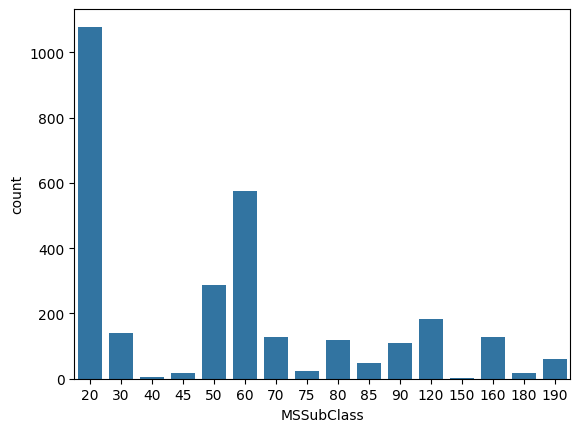

<Axes: xlabel='MSZoning', ylabel='count'>

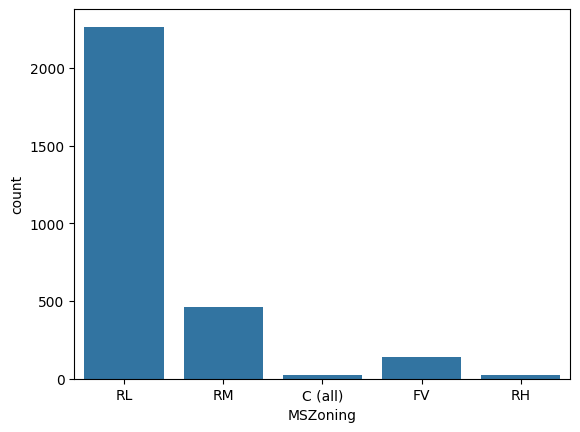

In [132]:
sns.countplot(data = blank, x="MSSubClass")
plt.show()
sns.countplot(data=blank,x="MSZoning")

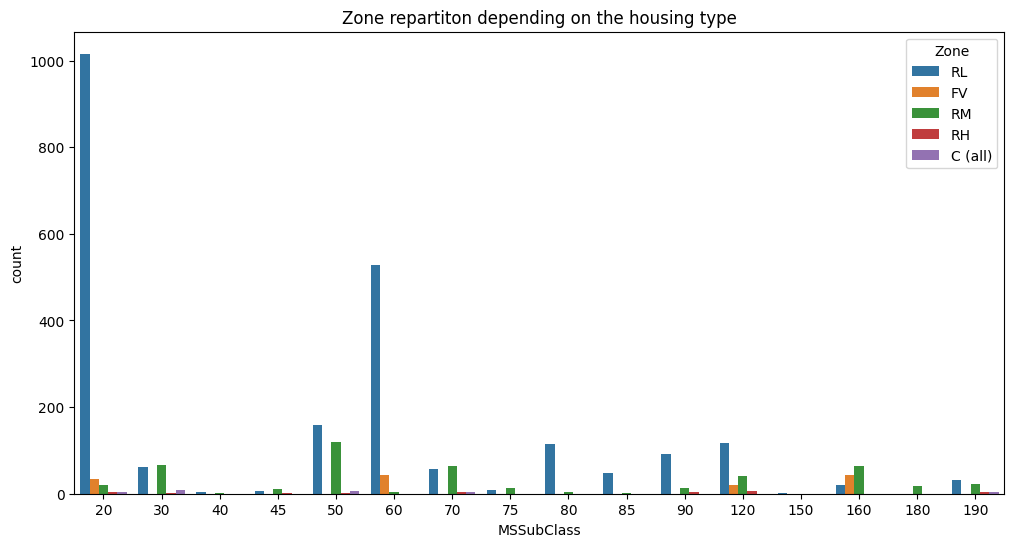

In [133]:
plt.figure(figsize=(12, 6))
sns.countplot(data=blank, x="MSSubClass", hue="MSZoning")
plt.title("Zone repartiton depending on the housing type")
plt.legend(title="Zone", loc='upper right')
plt.show()

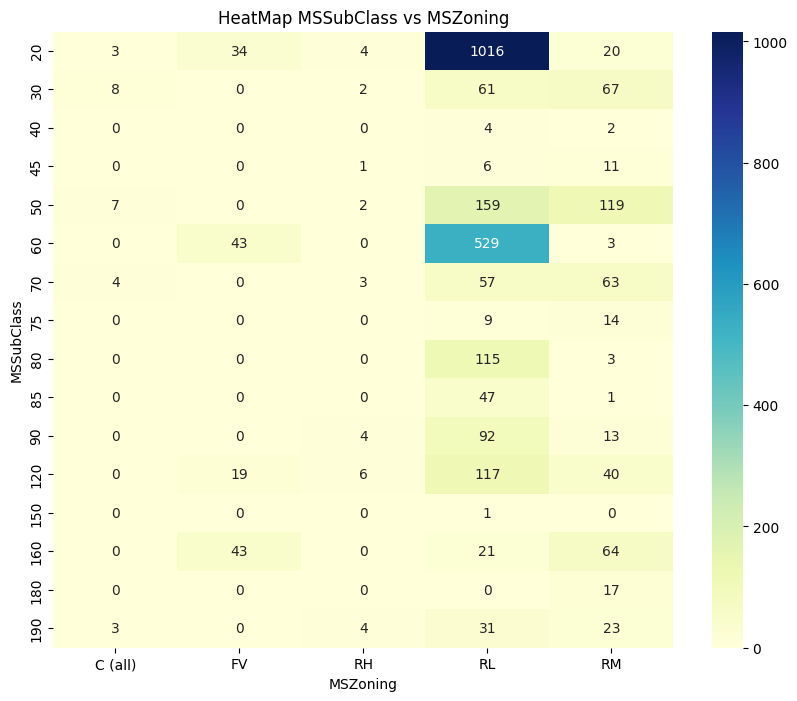

In [134]:
cross_tab = pd.crosstab(blank["MSSubClass"], blank["MSZoning"])
plt.figure(figsize=(10, 8))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("HeatMap MSSubClass vs MSZoning")
plt.show()

### Regarding this distribution we can already see that the dataset is pretty unbalanced and that most of the data is either zone RL (Residential Low density) or RM (Residential Medium density) and mostly sub class 20 (1-STORY 1946 & NEWER ALL STYLES) and 60 (2-STORY 1946 & NEWER).
### All that makes sense but it has to be taken in consideration, maybe we should focus on these categories to avoid overfitting 
### Let's keep on going deeper in the dataset analysis to find droppable features.

In [135]:
low_variance_cols = []
for col in blank.select_dtypes(include=['object']).columns:
    top_freq = blank[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95: # 95% threshold
        low_variance_cols.append((col, top_freq))

print("almost constant columns to drop :", low_variance_cols)

almost constant columns to drop : [('Street', np.float64(0.9958890030832477)), ('Utilities', np.float64(0.9996571820363387)), ('LandSlope', np.float64(0.9516957862281603)), ('Condition2', np.float64(0.9897225077081192)), ('RoofMatl', np.float64(0.9852689277149709)), ('Heating', np.float64(0.9845837615621789)), ('GarageCond', np.float64(0.9615942028985507))]


C:\Users\rabie\AppData\Local\Temp\ipykernel_81868\4016496448.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in blank.select_dtypes(include=['object']).columns:


### These columns are way too uniform to be kept, we will then drop them
### When it comes to subclasses and zoning we will perform some regrouping (6 for MSSubClasses and 3 for MSZoning) as the heatmap revealed so many combination are pointless compared to other ones

In [136]:
df_clean = blank.copy()

top_5_subclass = df_clean['MSSubClass'].value_counts().nlargest(5).index
df_clean['MSSubClass'] = df_clean['MSSubClass'].where(df_clean['MSSubClass'].isin(top_5_subclass), 'Other')

top_3_zoning = df_clean['MSZoning'].value_counts().nlargest(2).index
df_clean['MSZoning'] = df_clean['MSZoning'].where(df_clean['MSZoning'].isin(top_3_zoning), 'Other')



print(blank['MSSubClass'].value_counts())
print(df_clean['MSSubClass'].value_counts())
print(blank['MSZoning'].value_counts())
print(df_clean['MSZoning'].value_counts())

MSSubClass
20     1079
60      575
50      287
120     182
30      139
70      128
160     128
80      118
90      109
190      61
85       48
75       23
45       18
180      17
40        6
150       1
Name: count, dtype: int64
MSSubClass
20       1079
Other     657
60        575
50        287
120       182
30        139
Name: count, dtype: int64
MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64
MSZoning
RL       2265
RM        460
Other     194
Name: count, dtype: int64


In [137]:
to_drop, score = zip(*low_variance_cols)
to_drop = list(to_drop)
df_clean = df_clean.drop(columns=to_drop)

In [138]:
blank.info()

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   str    
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   str    
 6   Alley          198 non-null    str    
 7   LotShape       2919 non-null   str    
 8   LandContour    2919 non-null   str    
 9   Utilities      2917 non-null   str    
 10  LotConfig      2919 non-null   str    
 11  LandSlope      2919 non-null   str    
 12  Neighborhood   2919 non-null   str    
 13  Condition1     2919 non-null   str    
 14  Condition2     2919 non-null   str    
 15  BldgType       2919 non-null   str    
 16  HouseStyle     2919 non-null   str    
 17  OverallQual    2919 non-null   int64  
 18  OverallCond    2919

In [139]:
df_clean

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Alley,LotShape,LandContour,LotConfig,Neighborhood,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,NaN,Reg,Lvl,Inside,CollgCr,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,NaN,Reg,Lvl,FR2,Veenker,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,NaN,IR1,Lvl,Inside,CollgCr,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,Other,RL,60.0,9550,NaN,IR1,Lvl,Corner,Crawfor,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,NaN,IR1,Lvl,FR2,NoRidge,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,Other,RM,21.0,1936,NaN,Reg,Lvl,Inside,MeadowV,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
2915,2916,Other,RM,21.0,1894,NaN,Reg,Lvl,Inside,MeadowV,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
2916,2917,20,RL,160.0,20000,NaN,Reg,Lvl,Inside,Mitchel,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
2917,2918,Other,RL,62.0,10441,NaN,Reg,Lvl,Inside,Mitchel,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN


In [140]:
df_clean["Alley"].value_counts(), df_clean["Alley"].info()

<class 'pandas.Series'>
RangeIndex: 2919 entries, 0 to 2918
Series name: Alley
Non-Null Count  Dtype
--------------  -----
198 non-null    str  
dtypes: str(1)
memory usage: 22.9 KB


(Alley
 Grvl    120
 Pave     78
 Name: count, dtype: int64,
 None)

### Now we have to deal with NaN values, at least their type. We are going to isolate every column that features NaN value and decide if we should weather drop it or create a category. In order to do so i'll first give a look at the whole dataset and then decide what to do.

In [141]:
df_clean.to_csv("intermediatefile.csv",index=False)

In [142]:
cols_with_nan = df_clean.columns[df_clean.isnull().any()].tolist()
cols_with_nan

['LotFrontage',
 'Alley',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Electrical',
 'BsmtFullBath',
 'BsmtHalfBath',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SalePrice']

### from the data description file we can find that 14 columns with NaN values have a sense so we will just create categories to replace NaN so our model can use them. The features are the following ones :
* Alley
* BsmtQual
* BsmtCond
* BsmtExposure
* BsmtFinType1
* BsmtFinType2
* FireplaceQu
* GarageType
* GarageFinish
* GarageQual
* GarageCond
* PoolQC
* Fence
* MiscFeature

### Meaning the remaining columns are :
* MasVnrType
* MasVnrArea
* GarageYrBlt

### We'll look a bit deeper in these 3 columns to find out how to handle them


In [143]:
mask = df_clean['MasVnrType'].isnull()
df_clean['MasVnrType'][mask]

1       NaN
3       NaN
5       NaN
8       NaN
9       NaN
       ... 
2913    NaN
2914    NaN
2915    NaN
2916    NaN
2917    NaN
Name: MasVnrType, Length: 1766, dtype: str

### MasVnrType stands for Masonry veneer type, NaN relates to no masonry veneer type, we'll treat like the others

In [144]:
mask = df_clean['MasVnrType'].isnull()
mask1 = df_clean['MasVnrArea'].isnull()
print(df_clean['MasVnrArea'][mask1],len(df_clean['MasVnrArea'][mask1]))

mask2 = df_clean['MasVnrArea']==0
print(df_clean['MasVnrArea'][mask2],len(df_clean['MasVnrArea'][mask2]))

print(df_clean[['MasVnrArea','MasVnrType']][mask1])
#print(df_clean[['MasVnrArea','MasVnrType']][mask])
print(f""" We have {len(df_clean['MasVnrArea'][mask1])} NaN areas, and {len(df_clean['MasVnrArea'][mask2])} null areas for {len(df_clean['MasVnrType'][mask])} no masonry houses so overall 3 issues""" )


234    NaN
529    NaN
650    NaN
936    NaN
973    NaN
977    NaN
1243   NaN
1278   NaN
1691   NaN
1706   NaN
1882   NaN
1992   NaN
2004   NaN
2041   NaN
2311   NaN
2325   NaN
2340   NaN
2349   NaN
2368   NaN
2592   NaN
2657   NaN
2686   NaN
2862   NaN
Name: MasVnrArea, dtype: float64 23
1       0.0
3       0.0
5       0.0
8       0.0
9       0.0
       ... 
2913    0.0
2914    0.0
2915    0.0
2916    0.0
2917    0.0
Name: MasVnrArea, Length: 1738, dtype: float64 1738
      MasVnrArea MasVnrType
234          NaN        NaN
529          NaN        NaN
650          NaN        NaN
936          NaN        NaN
973          NaN        NaN
977          NaN        NaN
1243         NaN        NaN
1278         NaN        NaN
1691         NaN        NaN
1706         NaN        NaN
1882         NaN        NaN
1992         NaN        NaN
2004         NaN        NaN
2041         NaN        NaN
2311         NaN        NaN
2325         NaN        NaN
2340         NaN        NaN
2349         NaN       

### We can see here that the NaN are just errors and should be replace by 0 as there are no masonry so they can't have an area however we notice 3 properties without masonry dont have a null or NaN size (872 // 861+8)

In [145]:

col1 = "MasVnrType"
col2 = "MasVnrArea"
what = df_clean[df_clean[col1].isnull() & df_clean[col2].notnull() & (df_clean[col2] != 0)]

print(f"Errors found : {len(what)}")
what[[col1, col2]]

Errors found : 8


,MasVnrType,MasVnrArea
624,NaN,288.0
773,NaN,1.0
1230,NaN,1.0
1300,NaN,344.0
1334,NaN,312.0
1669,NaN,285.0
2452,NaN,1.0
2610,NaN,198.0


### For some reasons we found 5 errors here, no ideas why. We'll create an unknwon category.

In [146]:
mask = df_clean['GarageYrBlt'].isnull()
print(df_clean['GarageYrBlt'][mask])
# are there any garages built in year 0 ?
mask0 = df_clean['GarageYrBlt']==0
print(len(df_clean['GarageYrBlt'][mask0]))

mask1 = df_clean['GarageFinish'].isnull()
print(df_clean['GarageFinish'][mask1])



39     NaN
48     NaN
78     NaN
88     NaN
89     NaN
        ..
2893   NaN
2909   NaN
2913   NaN
2914   NaN
2917   NaN
Name: GarageYrBlt, Length: 159, dtype: float64
0
39      NaN
48      NaN
78      NaN
88      NaN
89      NaN
       ... 
2893    NaN
2909    NaN
2913    NaN
2914    NaN
2917    NaN
Name: GarageFinish, Length: 159, dtype: str


### No garages == no year of construcction obviously then we can also replace with something like 0 

### LotFrontage is a numerical variable that depicts the linear feet of streets connected to the property, we have to see to what a NaN corresponds. To 0 feet or to missing data

In [147]:
mask = df_clean['LotFrontage'].isnull()
df_clean[['LotFrontage','MSSubClass','MSZoning','LotShape','LotArea']][mask].to_csv("lotfrontage.csv",index=False)
df_clean[['LotFrontage','MSSubClass','MSZoning','LotShape','LotArea']][mask]

,LotFrontage,MSSubClass,MSZoning,LotShape,LotArea
7,NaN,60,RL,IR1,10382
12,NaN,20,RL,IR2,12968
14,NaN,20,RL,IR1,10920
16,NaN,20,RL,IR1,11241
24,NaN,20,RL,IR1,8246
...,...,...,...,...,...
2847,NaN,20,RL,Reg,11088
2850,NaN,60,RL,IR2,21533
2900,NaN,20,RL,IR1,50102
2901,NaN,20,RL,IR1,8098


### Pretty hard to gather any information or pattern here so we'll just replace that with the median lot frontage of the neighbor hood considering that if your neighboors have 50 feet of lot frontage then it is like that you do as well.

### To sum up :
* Unkown masonry type for the 5 ""outliers""
* None type for the other ones.
* 0 for every NaN masonry area
* 0 for each construction date of non existing garages
* Neighborhood lot frontage median for lot frontage
* None for each of the categories that didn't need any research

In [148]:
df_v2 = df_clean.copy()

In [149]:
df_v2['GarageYrBlt'] = df_v2['GarageYrBlt'].fillna(0)
print(f"remaining NaN in GarageYrBlt : {df_v2['GarageYrBlt'].isnull().sum()}")

remaining NaN in GarageYrBlt : 0


In [150]:
df_v2['MasVnrArea'] = df_v2['MasVnrArea'].fillna(0)
print(f"remaining NaN in MasVnrArea : {df_v2['MasVnrArea'].isnull().sum()}")

remaining NaN in MasVnrArea : 0


In [151]:
to_fix = df_v2[df_v2['MasVnrType'].isnull() & df_v2['MasVnrArea'].notnull() & (df_v2['MasVnrArea'] != 0)]
idx_to_fix = to_fix.index
df_v2.loc[idx_to_fix, 'MasVnrType'] = 'None' 
df_v2['MasVnrType'] = df_v2['MasVnrType'].fillna('Unknown')

print(f"Remaining NaN in MasVnrType : {df_v2['MasVnrType'].isnull().sum()}")
print("Final distribution :")
print(df_v2['MasVnrType'].value_counts())



Remaining NaN in MasVnrType : 0
Final distribution :
MasVnrType
Unknown    1758
BrkFace     879
Stone       249
BrkCmn       25
None          8
Name: count, dtype: int64


In [152]:
to_replace =['LotFrontage',
 'Alley',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'PoolQC',
 'Fence',
 'MiscFeature']

df_v2[to_replace].dtypes

LotFrontage     float64
Alley               str
BsmtQual            str
BsmtCond            str
BsmtExposure        str
BsmtFinType1        str
BsmtFinType2        str
Electrical          str
FireplaceQu         str
GarageType          str
GarageFinish        str
PoolQC              str
Fence               str
MiscFeature         str
dtype: object

In [153]:
df_v2['LotFrontage'] = df_v2.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
print(df_v2['LotFrontage'].isnull().sum())

0


In [154]:
to_replace_text = ['Alley', 
    'BsmtQual', 
    'BsmtCond', 
    'BsmtExposure', 
    'BsmtFinType1', 
    'BsmtFinType2', 
    'Electrical', 
    'FireplaceQu', 
    'GarageType', 
    'GarageFinish', 
    'PoolQC', 
    'Fence', 
    'MiscFeature']

df_v2[to_replace_text] = df_v2[to_replace_text].fillna('None')
print(df_v2[to_replace_text].isnull().sum())

Alley           0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
Electrical      0
FireplaceQu     0
GarageType      0
GarageFinish    0
PoolQC          0
Fence           0
MiscFeature     0
dtype: int64


In [155]:
cols_with_nan = df_v2.columns[df_v2.isnull().any()].tolist()
cols_with_nan

['Exterior1st',
 'Exterior2nd',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'KitchenQual',
 'Functional',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'SaleType',
 'SalePrice']

### df_v2 is now a complete and usable dataset for a first study. We'll be able to try some models and compare them.

In [156]:
dataset_a = df_v2.copy()

new_train = dataset_a.iloc[:train_len, :].copy()
new_test = dataset_a.iloc[train_len:, :].copy()

new_test.index = test_idx
if 'SalePrice' in new_test.columns:
    new_test = new_test.drop(columns=['SalePrice'])


new_train.to_csv('data/train_cleaned.csv', index=False)
new_test.to_csv('data/test_cleaned.csv', index=False)
print("Sucessfull export")

Sucessfull export
